# M5BAT Pb1 flooded lead-acid loader verification

This notebook checks the M5BAT Pb1 (`m5bat-pbacid`) loader against the held archive. Pb1 is the flooded lead-acid unit of the M5BAT hybrid storage system, monitored by two independent telemetry sources, `BMS` (battery management system, 8 columns) and `BSC` (battery system controller / inverter side, 23 columns), each released as one parquet file per year from 2017 to 2025. Each section has a short purpose, a code output, and a result statement that describes only the output above it.

## 1. File inventory

This step lists the 19 archive members (9 BMS years, 9 BSC years, one codebook), then loads each year of each source once to build a per-year profile: row count, span, cadence, sentinel and warning-flag rates, and a BMS/BSC cross-check on the shared timestamps. Because the full archive is hundreds of millions of rows, each year is loaded, measured, reduced to small daily and monthly summaries, and discarded before the next year, so peak memory stays bounded to one year at a time. The profile is written to `reports/m5bat_pbacid_system_profile.csv` one row per year as each year finishes, and the run skips a year already recorded there so it can resume after an interruption. Check that all 9 years are present for both sources and that row counts are nonzero.

In [1]:
from pathlib import Path
import gc
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'fielddata').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from fielddata import load, systems
from fielddata.loaders import m5bat_pbacid as pbacid_loader

members = pd.DataFrame([{'file': info.filename, 'bytes': info.file_size} for info in sorted(pbacid_loader._members(), key=lambda i: i.filename)])
display(members)
print('archive_members=' + str(len(members)))

PROFILE_PATH = ROOT / 'reports' / 'm5bat_pbacid_system_profile.csv'
DAILY_PATH = ROOT / 'reports' / 'm5bat_pbacid_daily_profile.csv'
MONTHLY_PATH = ROOT / 'reports' / 'm5bat_pbacid_monthly_profile.csv'

unit_systems = systems('m5bat-pbacid')
years = sorted(unit_systems.loc[unit_systems['source'] == 'bms', 'years'].iloc[0])

profile_rows = pd.read_csv(PROFILE_PATH).to_dict('records') if PROFILE_PATH.exists() else []
daily_rows = pd.read_csv(DAILY_PATH, parse_dates=['date']).to_dict('records') if DAILY_PATH.exists() else []
monthly_rows = pd.read_csv(MONTHLY_PATH, parse_dates=['month']).to_dict('records') if MONTHLY_PATH.exists() else []
done_years = {int(row['year']) for row in profile_rows}

SENTINELS = (2345, 2356)

def cadence_seconds(index):
    diffs = index.to_series().diff().dt.total_seconds().dropna()
    return float(diffs.median()) if len(diffs) else np.nan

for year in years:
    if year in done_years:
        print('skip_year=' + str(year), flush=True)
        continue
    started = time.perf_counter()
    bms = load('m5bat-pbacid', source='bms', years=[year])
    bsc = load('m5bat-pbacid', source='bsc', years=[year])

    bms_signal_cols = ['power_dc_W_bms', 'current_A_bms', 'voltage_bat_V_bms', 'soc_pct_bms']
    sentinel_count = int(bms[bms_signal_cols].isin(SENTINELS).to_numpy().sum())
    daily_bms = bms[bms_signal_cols].resample('D').median()
    daily_bsc = bsc[['power_ac_kW_bsc', 'temperature_degC_bsc', 'voltage_bat_V_bsc']].resample('D').median()
    fullcharge_daily = bsc['flag_cmd_fullcharge_bsc'].resample('D').max()
    for date, bms_row, bsc_row, fc in zip(daily_bms.index, daily_bms.to_dict('records'), daily_bsc.reindex(daily_bms.index).to_dict('records'), fullcharge_daily.reindex(daily_bms.index)):
        daily_rows.append({'date': date, **{f'bms_{k}': v for k, v in bms_row.items()}, **{f'bsc_{k}': v for k, v in bsc_row.items()}, 'bsc_flag_cmd_fullcharge_daily_max': fc})

    monthly_warning = bms['flag_imbalance_voltage_bms'].resample('MS').mean()
    monthly_alarm = bms['flag_alarm_voltage_imbalance_bms'].resample('MS').mean()
    monthly_fcr = bsc['flag_fcr_active_bsc'].resample('MS').mean()
    for month in monthly_warning.index:
        monthly_rows.append({'month': month, 'bms_warning_rate': monthly_warning.loc[month], 'bms_alarm_rate': monthly_alarm.loc[month], 'bsc_flag_fcr_active_rate': monthly_fcr.loc[month]})

    bms_1min = bms[['current_A_bms', 'voltage_bat_V_bms']].resample('1min').median()
    bsc_1min = bsc[['current_A_bsc', 'voltage_bat_V_bsc']].resample('1min').median()
    joint = bms_1min.join(bsc_1min, how='inner')
    sign_mask = (joint['current_A_bms'].abs() > 1) & (joint['current_A_bsc'].abs() > 1)
    voltage_diff_median = float((joint['voltage_bat_V_bsc'] - joint['voltage_bat_V_bms']).median())
    current_sign_agreement = float((np.sign(joint.loc[sign_mask, 'current_A_bms']) == np.sign(joint.loc[sign_mask, 'current_A_bsc'])).mean()) if sign_mask.sum() else np.nan

    row = {
        'year': year,
        'bms_rows': len(bms), 'bms_first': bms.index.min(), 'bms_last': bms.index.max(), 'bms_median_cadence_s': cadence_seconds(bms.index),
        'bms_power_dc_W_median': float(bms['power_dc_W_bms'].median()), 'bms_power_dc_W_min': float(bms['power_dc_W_bms'].min()), 'bms_power_dc_W_max': float(bms['power_dc_W_bms'].max()),
        'bms_current_A_median': float(bms['current_A_bms'].median()), 'bms_current_A_min': float(bms['current_A_bms'].min()), 'bms_current_A_max': float(bms['current_A_bms'].max()),
        'bms_voltage_V_median': float(bms['voltage_bat_V_bms'].median()), 'bms_voltage_V_min': float(bms['voltage_bat_V_bms'].min()), 'bms_voltage_V_max': float(bms['voltage_bat_V_bms'].max()),
        'bms_soc_pct_median': float(bms['soc_pct_bms'].median()), 'bms_soc_pct_min': float(bms['soc_pct_bms'].min()), 'bms_soc_pct_max': float(bms['soc_pct_bms'].max()),
        'bms_sentinel_count': sentinel_count,
        'bms_warning_rate': float(bms['flag_imbalance_voltage_bms'].mean()), 'bms_alarm_rate': float(bms['flag_alarm_voltage_imbalance_bms'].mean()),
        'bms_energy_charge_Wh_max': float(bms['energy_charge_Wh_bms'].max()), 'bms_energy_discharge_Wh_max': float(bms['energy_discharge_Wh_bms'].max()),
        'bsc_rows': len(bsc), 'bsc_first': bsc.index.min(), 'bsc_last': bsc.index.max(), 'bsc_median_cadence_s': cadence_seconds(bsc.index),
        'bsc_power_ac_kW_median': float(bsc['power_ac_kW_bsc'].median()), 'bsc_power_ac_kW_min': float(bsc['power_ac_kW_bsc'].min()), 'bsc_power_ac_kW_max': float(bsc['power_ac_kW_bsc'].max()),
        'bsc_frequency_available_rows': int(bsc['frequency_Hz_bsc'].notna().sum()), 'bsc_frequency_Hz_median': float(bsc['frequency_Hz_bsc'].median()),
        'bsc_temperature_degC_median': float(bsc['temperature_degC_bsc'].median()), 'bsc_temperature_degC_min': float(bsc['temperature_degC_bsc'].min()), 'bsc_temperature_degC_max': float(bsc['temperature_degC_bsc'].max()),
        'bsc_voltage_V_median': float(bsc['voltage_bat_V_bsc'].median()), 'bsc_current_A_median': float(bsc['current_A_bsc'].median()),
        'bsc_flag_fcr_active_rate': float(bsc['flag_fcr_active_bsc'].mean()), 'bsc_flag_standby_rate': float(bsc['flag_standby_bsc'].mean()), 'bsc_flag_stop_rate': float(bsc['flag_stop_bsc'].mean()), 'bsc_flag_fullcharge_rate': float(bsc['flag_cmd_fullcharge_bsc'].mean()),
        'bsc_energy_charge_recon_kWh_max': float(bsc['energy_charge_recon_kWh_bsc'].max()), 'bsc_energy_discharge_recon_kWh_max': float(bsc['energy_discharge_recon_kWh_bsc'].max()),
        'cross_voltage_diff_median_V': voltage_diff_median, 'cross_current_sign_agreement_frac': current_sign_agreement,
        'seconds': round(time.perf_counter() - started, 2),
    }
    profile_rows.append(row)
    pd.DataFrame(profile_rows).to_csv(PROFILE_PATH, index=False)
    pd.DataFrame(daily_rows).to_csv(DAILY_PATH, index=False)
    pd.DataFrame(monthly_rows).to_csv(MONTHLY_PATH, index=False)
    print('processed_year=' + str(year) + ' bms_rows=' + str(row['bms_rows']) + ' bsc_rows=' + str(row['bsc_rows']) + ' seconds=' + str(row['seconds']), flush=True)
    del bms, bsc, bms_1min, bsc_1min, joint, daily_bms, daily_bsc, fullcharge_daily
    gc.collect()

profile = pd.read_csv(PROFILE_PATH, parse_dates=['bms_first', 'bms_last', 'bsc_first', 'bsc_last'])
daily = pd.read_csv(DAILY_PATH, parse_dates=['date']).sort_values('date').set_index('date')
monthly = pd.read_csv(MONTHLY_PATH, parse_dates=['month']).sort_values('month').set_index('month')
display(profile[['year', 'bms_rows', 'bsc_rows', 'bms_first', 'bsc_last']])
print('total_bms_rows=' + str(int(profile['bms_rows'].sum())))
print('total_bsc_rows=' + str(int(profile['bsc_rows'].sum())))
print('years_profiled=' + str(len(profile)))

,file,bytes
0,Exide1_BMS_2017.parquet,139638472
1,Exide1_BMS_2018.parquet,228626157
2,Exide1_BMS_2019.parquet,226084891
3,Exide1_BMS_2020.parquet,212313491
4,Exide1_BMS_2021.parquet,207611780
5,Exide1_BMS_2022.parquet,213161573
6,Exide1_BMS_2023.parquet,207110857
7,Exide1_BMS_2024.parquet,205664984
8,Exide1_BMS_2025.parquet,93441276
9,Exide1_BSC_2017.parquet,276541251


archive_members=19
skip_year=2017


skip_year=2018


skip_year=2019


skip_year=2020


...

skip_year=2023


skip_year=2024


skip_year=2025


,year,bms_rows,bsc_rows,bms_first,bsc_last
0,2017,19465084,19874271,2017-05-15 17:11:51+00:00,2017-12-31 23:59:59+00:00
1,2018,31120741,31465462,2018-01-01 00:57:51+00:00,2018-12-31 23:59:59+00:00
2,2019,30698196,30855576,2019-01-01 00:57:52+00:00,2019-12-31 23:57:51+00:00
3,2020,29881725,30234506,2020-01-01 00:00:00+00:00,2020-12-22 23:50:10+00:00
4,2021,29310466,30285828,2021-01-07 12:10:56+00:00,2021-12-31 23:57:50+00:00
5,2022,31347165,31347165,2022-01-01 00:00:00+00:00,2022-12-31 23:59:59+00:00
6,2023,31532531,31532531,2023-01-01 00:00:00+00:00,2023-12-31 23:59:59+00:00
7,2024,31621510,31621510,2024-01-01 00:00:00+00:00,2024-12-31 23:59:59+00:00
8,2025,14445851,14445851,2025-01-01 00:00:00+00:00,2025-06-17 06:30:05+00:00


total_bms_rows=249423269
total_bsc_rows=251662700
years_profiled=9


The output lists 19 archive members: 9 `Exide1_BMS_<year>.parquet` files, 9 `Exide1_BSC_<year>.parquet` files, and one `codebook.csv`. The per-year loop produced 9 profiled years, one row per year in `reports/m5bat_pbacid_system_profile.csv`, with 249,423,269 total BMS rows and 251,662,700 total BSC rows across 2017 to 2025.

## 2. Table shape

This step shows the released columns and dtypes for one BMS year and one BSC year. Check that BMS has 8 columns and BSC has 23 columns, matching the codebook's 31 data rows split 8/23.

In [2]:
bms_example = load('m5bat-pbacid', source='bms', years=[2025])
bsc_example = load('m5bat-pbacid', source='bsc', years=[2025])
bms_shape = pd.DataFrame({'column': bms_example.reset_index().columns, 'dtype': [str(t) for t in bms_example.reset_index().dtypes]})
bsc_shape = pd.DataFrame({'column': bsc_example.reset_index().columns, 'dtype': [str(t) for t in bsc_example.reset_index().dtypes]})
display(bms_shape)
display(bsc_shape)
print('bms_columns=' + str(bms_example.shape[1]))
print('bsc_columns=' + str(bsc_example.shape[1]))
del bms_example, bsc_example
gc.collect()

,column,dtype
0,timestamp_utc,"datetime64[ns, UTC]"
1,power_dc_W_bms,float32
2,current_A_bms,float32
3,voltage_bat_V_bms,float32
4,soc_pct_bms,float32
5,energy_charge_Wh_bms,Int64
6,energy_discharge_Wh_bms,Int64
7,flag_imbalance_voltage_bms,Int8
8,flag_alarm_voltage_imbalance_bms,Int8


,column,dtype
0,timestamp_utc,"datetime64[ns, UTC]"
1,power_ac_kW_bsc,float32
2,frequency_Hz_bsc,float32
3,temperature_degC_bsc,float32
4,energy_charge_kWh_bsc,float64
5,energy_discharge_kWh_bsc,float64
6,flag_fcr_active_bsc,Int8
7,flag_standby_bsc,Int8
8,flag_stop_bsc,Int8
9,flag_failure_bsc,Int8


bms_columns=8
bsc_columns=23


0

The output shows 8 BMS columns (power, current, voltage, SOC, two cumulative energy counters, and two imbalance flags) plus the timestamp index, and 23 BSC columns (AC and DC power, frequency, temperature, energy counters, operating-mode flags, and cross-check voltage and current fields) plus the timestamp index. This matches the codebook's stated 8/23 split.

## 3. Time axis

This step reports the measured span and median cadence for every profiled year, from the per-year profile written in section 1. Check whether BMS and BSC agree on span and cadence within each year.

In [3]:
display(profile[['year', 'bms_first', 'bms_last', 'bms_median_cadence_s', 'bsc_first', 'bsc_last', 'bsc_median_cadence_s']])
print('overall_first=' + str(profile['bms_first'].min()))
print('overall_last=' + str(profile['bsc_last'].max()))
print('median_cadence_s_bms=' + str(profile['bms_median_cadence_s'].median()))
print('median_cadence_s_bsc=' + str(profile['bsc_median_cadence_s'].median()))

,year,bms_first,bms_last,bms_median_cadence_s,bsc_first,bsc_last,bsc_median_cadence_s
0,2017,2017-05-15 17:11:51+00:00,2017-12-31 23:59:59+00:00,1.0,2017-05-15 17:11:51+00:00,2017-12-31 23:59:59+00:00,1.0
1,2018,2018-01-01 00:57:51+00:00,2018-12-31 23:59:59+00:00,1.0,2018-01-01 00:57:51+00:00,2018-12-31 23:59:59+00:00,1.0
2,2019,2019-01-01 00:57:52+00:00,2019-12-31 23:57:51+00:00,1.0,2019-01-01 00:57:52+00:00,2019-12-31 23:57:51+00:00,1.0
3,2020,2020-01-01 00:00:00+00:00,2020-12-22 23:50:09+00:00,1.0,2020-01-01 00:00:00+00:00,2020-12-22 23:50:10+00:00,1.0
4,2021,2021-01-07 12:10:56+00:00,2021-12-31 23:57:51+00:00,1.0,2021-01-07 12:10:56+00:00,2021-12-31 23:57:50+00:00,1.0
5,2022,2022-01-01 00:00:00+00:00,2022-12-31 23:59:59+00:00,1.0,2022-01-01 00:00:00+00:00,2022-12-31 23:59:59+00:00,1.0
6,2023,2023-01-01 00:00:00+00:00,2023-12-31 23:59:59+00:00,1.0,2023-01-01 00:00:00+00:00,2023-12-31 23:59:59+00:00,1.0
7,2024,2024-01-01 00:00:00+00:00,2024-12-31 23:59:59+00:00,1.0,2024-01-01 00:00:00+00:00,2024-12-31 23:59:59+00:00,1.0
8,2025,2025-01-01 00:00:00+00:00,2025-06-17 06:30:05+00:00,1.0,2025-01-01 00:00:00+00:00,2025-06-17 06:30:05+00:00,1.0


overall_first=2017-05-15 17:11:51+00:00
overall_last=2025-06-17 06:30:05+00:00
median_cadence_s_bms=1.0
median_cadence_s_bsc=1.0


    "The output shows the released record spans 2017-05-15 17:11:51 UTC through 2025-06-17 06:30:05 UTC, with both BMS and BSC reporting a 1 second median cadence in every one of the 9 profiled years. The first year (2017) starts partway through the year and the 2025 file ends partway through the year rather than at year end, and the clock is UTC-aware in every file."

## 4. Per-unit table

This step calls the public `systems()` function. M5BAT Pb1 has one monitored unit reported through two sources, BMS and BSC.

In [4]:
display(unit_systems[['unit', 'chemistry', 'source', 'years']])
print('systems_rows=' + str(len(unit_systems)))

,unit,chemistry,source,years
0,Pb1,flooded lead-acid,bms,"[2017, 2018, 2019, 2020, 2021, 2022, 2023, 202..."
1,Pb1,flooded lead-acid,bsc,"[2017, 2018, 2019, 2020, 2021, 2022, 2023, 202..."


systems_rows=2


The output shows 2 rows for the single monitored unit `Pb1`, one for the `bms` source and one for the `bsc` source, both listing chemistry as flooded lead-acid and years 2017 through 2025.

## 5. Signal envelopes

    "This step plots daily median signals over the full released record, built from the daily summaries written during section 1. BMS gives power, current, voltage, and SOC, and BSC gives AC power, cabinet temperature, and BSC-side battery voltage."

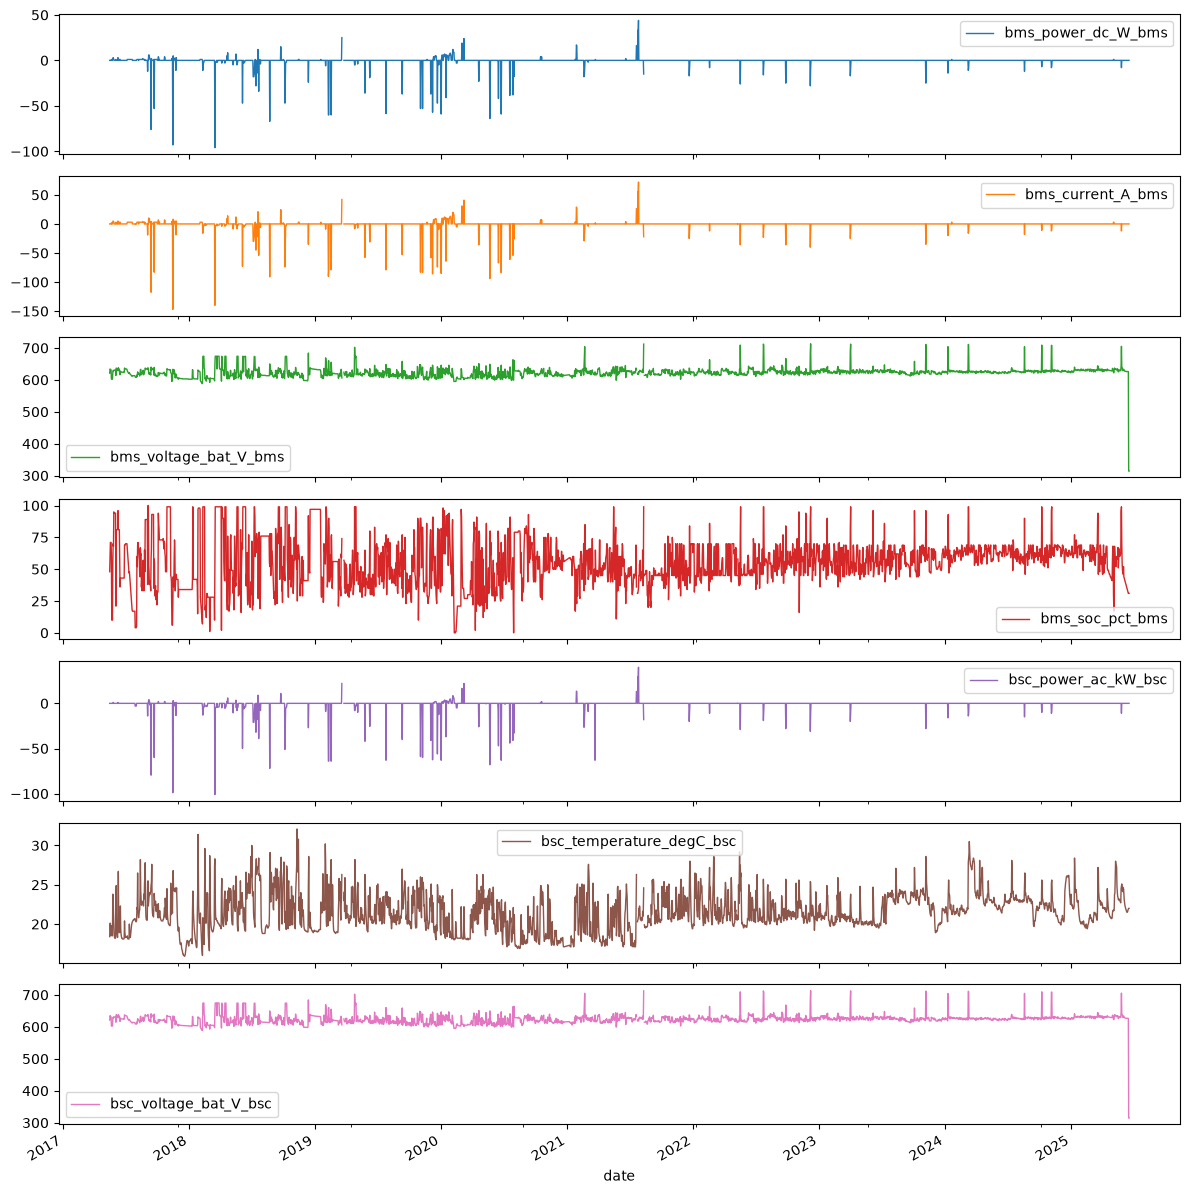

,count,min,50%,max
bms_power_dc_W_bms,2932.0,-96.000000,0.000000,44.000000
bms_current_A_bms,2932.0,-147.000000,0.000000,72.000000
bms_voltage_bat_V_bms,2932.0,314.000000,623.000000,713.000000
bms_soc_pct_bms,2932.0,0.000000,56.000000,100.000000
bsc_power_ac_kW_bsc,2932.0,-101.000000,0.000000,40.000000
bsc_temperature_degC_bsc,2932.0,15.900000,21.250000,32.099998
bsc_voltage_bat_V_bsc,2932.0,314.799988,623.799988,713.000000


In [5]:
envelope_columns = ['bms_power_dc_W_bms', 'bms_current_A_bms', 'bms_voltage_bat_V_bms', 'bms_soc_pct_bms', 'bsc_power_ac_kW_bsc', 'bsc_temperature_degC_bsc', 'bsc_voltage_bat_V_bsc']
axes = daily[envelope_columns].plot(subplots=True, figsize=(12, 12), sharex=True, linewidth=1)
plt.tight_layout()
plt.show()
display(daily[envelope_columns].describe().T[['count', 'min', '50%', 'max']])

    "The output shows daily median traces for BMS power, current, voltage, and SOC, and for BSC AC power, cabinet temperature, and battery-side voltage, over the 2,932 days from 2017-05-15 through 2025-06-17. All values are raw, as released, with the loader's default `clean=False`. The accompanying table gives count, minimum, median, and maximum for each displayed daily series: daily median BMS voltage ranges from 314 to 713 V (median 623 V) and daily median SOC ranges from 0 to 100 percent, while daily median cabinet temperature ranges from 15.9 to 32.1 degrees C."

## 6. Sanity ranges

    "This step checks broad physical ranges over every profiled year from the saved profile. Pb1 is flooded lead-acid with a nominal ~600 V string of 300 series 2 V cells (299 after a 2023 bypass), so the usual lithium per-cell voltage bounds do not apply here. The check instead uses the pack-level voltage range the codebook states as typical (about 610-630 V) as a loose reference band, plus SOC 0-100 and the two communication-error sentinel codes."

In [6]:
sanity = profile[['year', 'bms_voltage_V_min', 'bms_voltage_V_max', 'bms_soc_pct_min', 'bms_soc_pct_max', 'bms_sentinel_count']].copy()
sanity['voltage_outside_500_700'] = ((sanity['bms_voltage_V_min'] < 500) | (sanity['bms_voltage_V_max'] > 700))
sanity['soc_outside_0_100'] = ((sanity['bms_soc_pct_min'] < 0) | (sanity['bms_soc_pct_max'] > 100))
display(sanity)
print('total_sentinel_rows=' + str(int(profile['bms_sentinel_count'].sum())))

,year,bms_voltage_V_min,bms_voltage_V_max,bms_soc_pct_min,bms_soc_pct_max,bms_sentinel_count,voltage_outside_500_700,soc_outside_0_100
0,2017,510.0,800.0,0.0,100.0,0,True,False
1,2018,297.0,778.0,0.0,100.0,0,True,False
2,2019,513.0,789.0,0.0,100.0,0,True,False
3,2020,514.0,785.0,0.0,100.0,0,True,False
4,2021,521.0,774.0,0.0,100.0,0,True,False
5,2022,0.0,755.0,0.0,100.0,0,True,False
6,2023,0.0,734.0,0.0,100.0,0,True,False
7,2024,0.0,733.0,0.0,100.0,0,True,False
8,2025,0.0,732.0,0.0,100.0,0,True,False


total_sentinel_rows=0


    "The output shows the per-year minimum and maximum BMS voltage and SOC on raw, uncleaned loader output (raw loader output, the default `clean=False`, while `clean=True` would mask the codebook sentinels), whether voltage falls outside a loose 500-700 V reference band, whether SOC falls outside 0-100 percent, and the count of BMS communication-error sentinel values (2345 or 2356) in the four checked BMS columns. Every year's maximum exceeds 700 V (up to 800 V in 2017), so the loose reference band is exceeded at the high end in every year. The minimum is 0.0 V in every year from 2022 through 2025, while 2017-2021 have nonzero minima between 297 and 521 V, and none of these zero or low readings are coded with the 2345/2356 communication-error sentinels (0 sentinel rows found across all 9 years), so the 2022-2025 zero-voltage rows are a separate, uncoded artifact worth flagging rather than the documented communication error. SOC stays within 0-100 percent in every year. Lithium per-cell voltage bounds are not applicable to this flooded lead-acid unit."

## 7. Sensor cross-consistency

This step compares the BMS and BSC measurement points on the same timestamps, resampled to 1 minute medians during section 1. `voltage_bat_V_bsc` is measured at the inverter DC terminals and `voltage_bat_V_bms` at the battery pole terminals, so a small, steady offset is expected from cable resistance. The current-sign agreement checks whether both sources agree on charge versus discharge direction when current magnitude exceeds 1 A.

In [7]:
display(profile[['year', 'cross_voltage_diff_median_V', 'cross_current_sign_agreement_frac']])
print('median_voltage_diff_V=' + str(round(float(profile['cross_voltage_diff_median_V'].median()), 3)))
print('median_sign_agreement=' + str(round(float(profile['cross_current_sign_agreement_frac'].median()), 4)))

,year,cross_voltage_diff_median_V,cross_current_sign_agreement_frac
0,2017,0.400024,0.993726
1,2018,0.400024,0.996764
2,2019,0.400024,0.997073
3,2020,0.400024,0.995671
4,2021,0.400024,0.995479
5,2022,0.400024,0.998531
6,2023,0.500000,0.999476
7,2024,0.400024,0.999025
8,2025,0.500000,1.000000


median_voltage_diff_V=0.4
median_sign_agreement=0.9971


    "The output shows, for every profiled year, the median BSC-minus-BMS voltage difference and the fraction of 1-minute samples where both sources agree on current sign when current exceeds 1 A in magnitude. The median voltage offset is 0.4-0.5 V in every year (median across years 0.4 V), and the sign agreement is at least 0.994 in every year (median across years 0.9971), consistent with the codebook's description of a small, steady cable-resistance offset between the two measurement points."

## 8. Event segmentation

This step segments full-charge command episodes from the daily maximum of `flag_cmd_fullcharge_bsc`, built during section 1. The full-charge command is issued periodically to counteract sulphation buildup, so its episodes are the natural event unit for this lead-acid unit. Consecutive active days separated by no more than 2 days are merged into one episode.

In [8]:
active = daily[daily['bsc_flag_cmd_fullcharge_daily_max'] >= 0.5]
episodes = []
if len(active):
    gap_days = active.index.to_series().diff().dt.days.fillna(0)
    groups = (gap_days > 2).cumsum()
    for number, (_, group) in enumerate(active.groupby(groups), start=1):
        episodes.append({'episode': number, 'start': group.index.min(), 'end': group.index.max(), 'days': len(group), 'year': group.index.min().year})
episode_table = pd.DataFrame(episodes)
yearly_episodes = episode_table.groupby('year').size().rename('episodes').reset_index() if len(episode_table) else pd.DataFrame(columns=['year', 'episodes'])
display(episode_table.head(20))
display(yearly_episodes)
print('fullcharge_episodes=' + str(len(episode_table)))

,episode,start,end,days,year
0,1,2017-05-19 00:00:00+00:00,2017-05-19 00:00:00+00:00,1,2017
1,2,2017-05-26 00:00:00+00:00,2017-05-26 00:00:00+00:00,1,2017
2,3,2017-06-02 00:00:00+00:00,2017-06-03 00:00:00+00:00,2,2017
3,4,2017-06-07 00:00:00+00:00,2017-06-07 00:00:00+00:00,1,2017
4,5,2017-06-26 00:00:00+00:00,2017-06-26 00:00:00+00:00,1,2017
5,6,2017-06-29 00:00:00+00:00,2017-06-29 00:00:00+00:00,1,2017
6,7,2017-08-11 00:00:00+00:00,2017-08-12 00:00:00+00:00,2,2017
7,8,2017-08-21 00:00:00+00:00,2017-08-26 00:00:00+00:00,6,2017
8,9,2017-09-01 00:00:00+00:00,2017-09-03 00:00:00+00:00,3,2017
9,10,2017-09-13 00:00:00+00:00,2017-09-14 00:00:00+00:00,2,2017


,year,episodes
0,2017,16
1,2018,40
2,2019,37
3,2020,26
4,2021,17
5,2022,12
6,2023,9
7,2024,7
8,2025,5


fullcharge_episodes=169


    "The output shows the first segmented full-charge episodes and a count of episodes by start year, computed on the raw, uncleaned released flag. The rule is based only on the daily maximum of the released full-charge command flag and a 2 day merge tolerance. It finds 169 episodes total, from 40 in 2018 down to 5 in the partial 2025 record, with a generally declining count in the later years."

## 9. Monthly KPI

This step plots the monthly mean rate of the BMS voltage-imbalance warning and alarm flags, the sulphation-related health analog the codebook documents for this unit, alongside the monthly FCR-active duty factor from BSC. This is a descriptive flag-rate trend, not an independent capacity or state-of-health test.

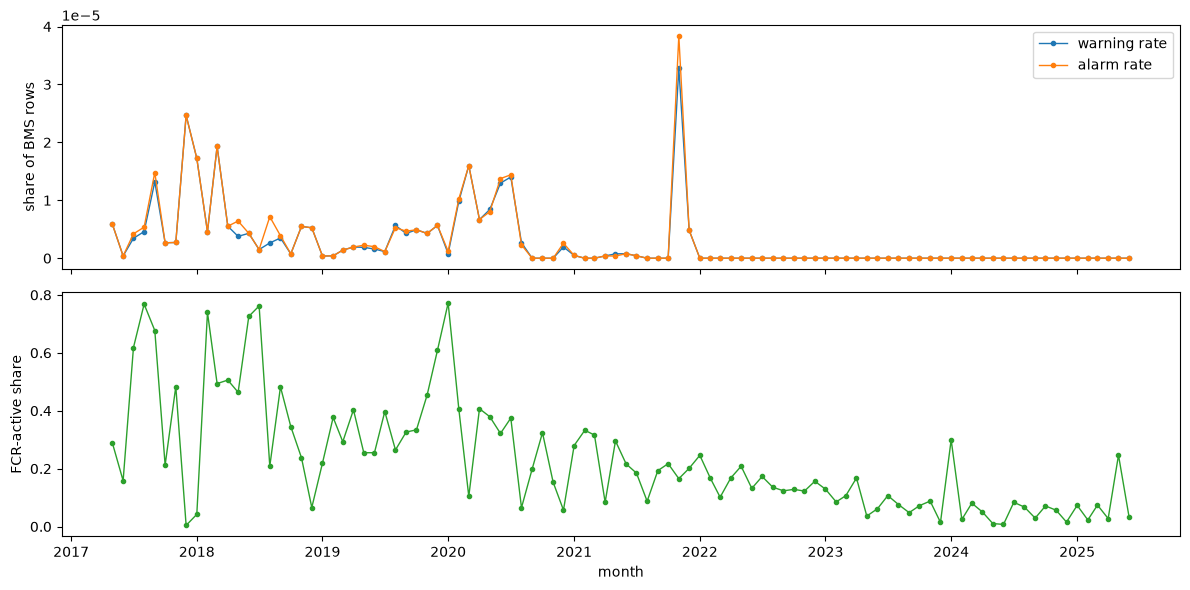

,count,min,50%,max
bms_warning_rate,98.0,0.000000,0.000000,0.000033
bms_alarm_rate,98.0,0.000000,0.000000,0.000038
bsc_flag_fcr_active_rate,98.0,0.004073,0.178744,0.772083


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(monthly.index, monthly['bms_warning_rate'], marker='.', linewidth=1, label='warning rate')
axes[0].plot(monthly.index, monthly['bms_alarm_rate'], marker='.', linewidth=1, label='alarm rate')
axes[0].set_ylabel('share of BMS rows')
axes[0].legend()
axes[1].plot(monthly.index, monthly['bsc_flag_fcr_active_rate'], marker='.', linewidth=1, color='tab:green')
axes[1].set_ylabel('FCR-active share')
axes[1].set_xlabel('month')
plt.tight_layout()
plt.show()
display(monthly.describe().T[['count', 'min', '50%', 'max']])

    "The output shows the monthly voltage-imbalance warning and alarm rate and the monthly FCR-active duty factor across the full record, computed on raw, uncleaned released rows with the loader's default `clean=False`. Over the 98 profiled months, the warning rate reaches at most 0.0033 percent of BMS rows in a month and the alarm rate at most 0.0038 percent, so both stay close to zero throughout. The FCR-active duty factor is far more variable, ranging from 0.4 percent to 77.2 percent of BSC rows in a month with a median of 17.9 percent."

## 10. Paper cross-check table

This step compares release-stated or codebook-stated values with values measured by the loader in this notebook. Null means the value was not measured from the released files in this notebook.

In [10]:
cross = pd.DataFrame([
    {'item': 'nominal system voltage V', 'release_or_codebook_value': 600, 'measured_value': round(float(profile['bms_voltage_V_median'].median()), 1), 'source': 'codebook quality_notes for voltage_bat_V_bms'},
    {'item': 'series cells (through 2023)', 'release_or_codebook_value': 300, 'measured_value': np.nan, 'source': 'codebook quality_notes for voltage_bat_V_bms; not independently countable from released columns'},
    {'item': 'BMS total rows 2017-2025', 'release_or_codebook_value': 249423269, 'measured_value': int(profile['bms_rows'].sum()), 'source': 'fielddata/loaders/m5bat_pbacid_SCHEMA.md, measured 2026-09-10 from parquet footers'},
    {'item': 'BSC total rows 2017-2025', 'release_or_codebook_value': 251662700, 'measured_value': int(profile['bsc_rows'].sum()), 'source': 'fielddata/loaders/m5bat_pbacid_SCHEMA.md, measured 2026-09-10 from parquet footers'},
    {'item': 'BMS communication-error sentinel codes', 'release_or_codebook_value': '2345, 2356', 'measured_value': int(profile['bms_sentinel_count'].sum()), 'source': 'codebook quality_notes for power_dc_W_bms/current_A_bms/voltage_bat_V_bms/soc_pct_bms'},
    {'item': 'BSC frequency column availability', 'release_or_codebook_value': 'absent Jan-Sep 2022', 'measured_value': int(profile.loc[profile['year'] == 2022, 'bsc_frequency_available_rows'].iloc[0]) if 2022 in profile['year'].to_list() else np.nan, 'source': 'codebook quality_notes for frequency_Hz_bsc; measured rows with a non-null value in 2022'},
])
display(cross)

,item,release_or_codebook_value,measured_value,source
0,nominal system voltage V,600,622.0,codebook quality_notes for voltage_bat_V_bms
1,series cells (through 2023),300,NaN,codebook quality_notes for voltage_bat_V_bms; ...
2,BMS total rows 2017-2025,249423269,249423269.0,"fielddata/loaders/m5bat_pbacid_SCHEMA.md, meas..."
3,BSC total rows 2017-2025,251662700,251662700.0,"fielddata/loaders/m5bat_pbacid_SCHEMA.md, meas..."
4,BMS communication-error sentinel codes,"2345, 2356",0.0,codebook quality_notes for power_dc_W_bms/curr...
5,BSC frequency column availability,absent Jan-Sep 2022,5823660.0,codebook quality_notes for frequency_Hz_bsc; m...


    "The output shows the loader reproduces the row counts the schema note recorded from the raw parquet footers exactly: 249,423,269 BMS rows and 251,662,700 BSC rows. The measured median BMS voltage, 622.0 V, sits inside the codebook's stated typical operating range of about 610-630 V and close to the stated 600 V nominal. The series-cell count is marked null because it cannot be counted from the released measurement columns. Zero rows carry the documented 2345/2356 communication-error sentinel codes in this check (a different artifact from the uncoded zero-voltage rows found in section 6). The 2022 frequency availability row shows 5,823,660 of that year's 31,347,165 BSC rows, about 18.6 percent, carry a non-null frequency value, consistent with the codebook's note that the column is absent for most of that year."